<!-- NOTEBOOK_THEME_START -->
<style>
/* Professional WQU notebook theme. */
.jp-Notebook {
  max-width: 1120px;
  margin: 0 auto;
}
.jp-RenderedHTMLCommon {
  color: #243447;
  font-family: Arial, Calibri, sans-serif;
  font-size: 10pt;
  line-height: 1.55;
    text-align: justify;
    text-align-last: center;
    width: 100%;
    box-sizing: border-box;
}
.jp-RenderedHTMLCommon p:not(.plot-description),
.jp-RenderedHTMLCommon blockquote,
.jp-RenderedHTMLCommon li,
.jp-RenderedHTMLCommon table,
.jp-RenderedHTMLCommon th,
.jp-RenderedHTMLCommon td {
    font-family: Arial, Calibri, sans-serif !important;
    font-size: 10pt !important;
    font-style: normal !important;
    line-height: 1.55 !important;
    letter-spacing: 0px !important;
}
.jp-RenderedHTMLCommon h1,
.jp-RenderedHTMLCommon h2,
.jp-RenderedHTMLCommon h3,
.jp-RenderedHTMLCommon h4 {
    text-align: center;
    text-align-last: center;
}
.jp-RenderedHTMLCommon p {
    text-align: justify;
    text-align-last: center;
}
.jp-RenderedHTMLCommon ul,
.jp-RenderedHTMLCommon ol {
    padding-left: 0;
    text-align: center;
    text-align-last: center;
}
.jp-RenderedHTMLCommon li {
    list-style-position: inside;
    text-align: center;
    text-align-last: center;
}
.jp-RenderedHTMLCommon h1 {
  color: #28345c;
  border-bottom: 2px solid #465b8c;
  padding-bottom: 0.3rem;
}
.jp-RenderedHTMLCommon h2 {
  color: #1f6f9f;
  margin-top: 1.7rem;
}
.jp-RenderedHTMLCommon h3,
.jp-RenderedHTMLCommon h4 {
  color: #355070;
}
.jp-RenderedHTMLCommon blockquote {
  background: #f4f7fb;
  border-left: 4px solid #4b7f9f;
  color: #263849;
  margin: 1rem 0;
  padding: 0.7rem 1rem;
}
.jp-RenderedHTMLCommon table {
  border-collapse: collapse;
    margin-left: auto;
    margin-right: auto;
        text-align: center !important;
        text-align-last: center !important;
    width: 100%;
}
.jp-RenderedHTMLCommon th,
.jp-RenderedHTMLCommon td {
    text-align: center !important;
    text-align-last: center !important;
}
.jp-RenderedHTMLCommon th {
  background: #e9eef6;
  color: #28345c;
}
.jp-RenderedHTMLCommon img {
    display: block;
    margin-left: auto;
    margin-right: auto;
}
.jp-RenderedHTMLCommon mjx-container[display="true"],
.jp-RenderedHTMLCommon .MathJax_Display {
  margin: 1.1rem 0 !important;
  overflow-x: auto;
  overflow-y: hidden;
}
.jp-RenderedHTMLCommon .mjx-label .mjx-mstyle > .mjx-mrow {
    font-size: 85.5% !important;
}
.jp-RenderedHTMLCommon p.plot-description {
    font-size: 8pt !important;
  line-height: 1.3;
  color: #444;
  margin: 0.25rem 0 1rem;
        text-align: center !important;
        text-align-last: center !important;
}
</style>
<!-- NOTEBOOK_THEME_END -->

# MScFE 622 - Stochastic Modeling
## Group Work Project 1

This is the complete analytical deliverable for the project brief. It includes the model setup, calibration choices, numerical validation, pricing results, interpretations, and figures for Steps 1-3. Inputs are hidden in the presentation view so that the narrative and results remain readable; run the notebook from top to bottom to refresh every result.

**Common assumptions.** SM Energy spot is $232.90; one year contains 250 trading days; the initial annual risk-free rate is 1.50%; and no dividend yield is specified, so it is set to zero. All option prices are USD.

In [1]:
get_ipython().run_line_magic("load_ext", "stochastic_modeling.notebook_runtime")

Workflow initialized with the project assumptions and pricing engines.


## Data and quality checks

The market file is read directly from the supplied data directory. The brief requests a separate short-dated calibration (15 days) and a medium-dated calibration (60 days); 120-day observations are retained only as source data and are not used in either calibration.

In [2]:
show_data_quality_checks()

,days,strike,price,type,T
0,15,227.5,10.52,C,0.06
1,15,230.0,10.05,C,0.06
2,15,232.5,7.75,C,0.06
3,15,235.0,6.01,C,0.06
4,15,237.5,4.75,C,0.06
5,60,227.5,16.78,C,0.24
6,60,230.0,17.65,C,0.24
7,60,232.5,16.86,C,0.24
8,60,235.0,16.05,C,0.24
9,60,237.5,15.10,C,0.24


Source: options.csv; observations: 30


# Step 1 - Short maturity (15 days)

## 1(i) Heston (1993) calibrated with the Lewis (2001) representation

> **Heston model purpose.** The Heston model represents equity returns with a variance that changes randomly through time and can be correlated with stock-price shocks. It therefore captures volatility clustering, mean reversion, and the implied-volatility skew that a constant-volatility model cannot reproduce.

Under the risk-neutral measure, the stock and instantaneous variance follow the Heston diffusion (Heston 327-343):

**Parameters (Equations 1-3).** $S_t$ is the stock price and $v_t$ is its instantaneous variance at time $t$; $r$ is the continuously compounded risk-free rate and $dt$ is an infinitesimal time increment. $W_t^S$ and $W_t^v$ are Brownian motions driving price and variance. The variance parameters are mean-reversion speed $\kappa$, long-run variance $\theta$, volatility of variance $\sigma$, correlation $\rho$ between the Brownian shocks, and initial variance $v_0$.

$$
dS_t=rS_t\,dt+\sqrt{v_t}S_t\,dW_t^S. \tag*{$\scriptstyle (1)$}
$$

$$
dv_t=\kappa(\theta-v_t)\,dt+\sigma\sqrt{v_t}\,dW_t^v. \tag*{$\scriptstyle (2)$}
$$

$$
dW_t^S\,dW_t^v=\rho\,dt. \tag*{$\scriptstyle (3)$}
$$

The parameter vector is $(\kappa,\theta,\sigma,\rho,v_0)$. Define the characteristic function of the log return as

**Parameters (Equation 4).** $\varphi_T(z)$ is the characteristic function of the log return over maturity $T$ at complex Fourier argument $z$; $i=\sqrt{-1}$, $S_0$ and $S_T$ are the initial and terminal stock prices, and $\mathbb{E}^{\mathbb{Q}}$ denotes expectation under the risk-neutral measure $\mathbb{Q}$.

$$
\varphi_T(z)=\mathbb{E}^{\mathbb{Q}}\!\left[e^{iz\log(S_T/S_0)}\right]. \tag*{$\scriptstyle (4)$}
$$

The Lewis representation used for calls is (Lewis):

> **Lewis representation purpose.** Lewis converts the Heston characteristic function into a stable one-dimensional Fourier integral for European call values; put values then follow from put-call parity.

**Parameters (Equations 5-6).** $C_0$ and $P_0$ are today's European call and put values; $S_0$ is spot, $K$ is strike, $T$ is time to maturity, and $r$ is the risk-free rate. $u$ is the Fourier integration variable, $i=\sqrt{-1}$, $\operatorname{Re}[\cdot]$ takes the real part, $\pi$ is the circle constant, and $\varphi_T$ is the Heston characteristic function from Equation (4).

$$
C_0=S_0-\frac{e^{-rT}\sqrt{S_0K}}{\pi}
\int_0^{\infty}\operatorname{Re}\!\left[
\frac{e^{iu\log(S_0/K)}\varphi_T(u-i/2)}{u^2+1/4}
\right]du. \tag*{$\scriptstyle (5)$}
$$

Puts are obtained through the preferred parity relation specified in the project brief (WorldQuant University 1-2):

$$
P_0=C_0-S_0+Ke^{-rT}. \tag*{$\scriptstyle (6)$}
$$

The calibration uses all five 15-day calls and all five 15-day puts with the requested unweighted dollar-price MSE:

**Parameters (Equation 7).** $\Theta$ is the trial Heston parameter vector; $N=10$ is the number of option quotes and $i$ indexes them. $V_i^{\mathrm{model}}(\Theta)$ and $V_i^{\mathrm{market}}$ are the model and observed USD prices, respectively, and $\operatorname{MSE}$ is their mean squared pricing error.

$$
\operatorname{MSE}(\Theta)=\frac{1}{N}\sum_{i=1}^{N}
\left(V_i^{\mathrm{model}}(\Theta)-V_i^{\mathrm{market}}\right)^2,
\qquad N=10. \tag*{$\scriptstyle (7)$}
$$

### Calibration procedure

1. Retain exactly the five calls and five puts with 15 trading days to maturity and set $T=15/250=0.06$ years.
2. For each trial parameter vector, evaluate calls from Equation (5) and derive puts from Equation (6), using the common spot and 1.50% risk-free rate.
3. Minimize Equation (7) in dollar-price space. A seeded differential-evolution search first explores the bounded parameter region; bounded nonlinear least squares then refines the candidate using the ten individual residuals.
4. Assess the result using MSE, RMSE, option-level residuals, put-call parity, parameter bounds, and the Feller diagnostic $2\kappa\theta-\sigma^2$. This separates numerical fit from data inconsistency and parameter-identification risk.

In [3]:
show_pricing_method_configuration()

,pricing method,put treatment,calibration objective
0,Lewis (2001),put-call parity,unweighted price MSE
1,Carr-Madan (1999),put-call parity,unweighted price MSE


In [4]:
show_heston_lewis_calibration()

,strike,C - P,parity value,gap
0,227.5,6.20,5.6047,0.5953
1,230.0,4.85,3.1069,1.7431
2,232.5,1.30,0.6092,0.6908
3,235.0,-1.55,-1.8886,0.3386
4,237.5,-4.03,-4.3863,0.3563


Put-call parity RMSE: $0.9068; irreducible joint-price RMSE floor: $0.4534


,days,strike,price,type,T,model,residual,squared_error
0,15,227.5,10.52,C,0.06,10.5134,-0.0066,0.0000
1,15,230.0,10.05,C,0.06,8.8590,-1.1910,1.4184
2,15,232.5,7.75,C,0.06,7.3207,-0.4293,0.1843
3,15,235.0,6.01,C,0.06,5.9073,-0.1027,0.0106
4,15,237.5,4.75,C,0.06,4.6273,-0.1227,0.0150
5,15,227.5,4.32,P,0.06,4.9087,0.5887,0.3466
6,15,230.0,5.20,P,0.06,5.7521,0.5521,0.3049
7,15,232.5,6.45,P,0.06,6.7116,0.2616,0.0684
8,15,235.0,7.56,P,0.06,7.7958,0.2358,0.0556
9,15,237.5,8.78,P,0.06,9.0137,0.2337,0.0546


,kappa,theta,sigma,rho,v0,MSE,RMSE,Feller diagnostic
0,2.203249,0.001,1.273325,-0.944421,0.108413,0.245839,0.495821,-1.616951


#### Calibration discussion

**Fit quality.** The joint calibration has RMSE $0.4958. The quotes imply a minimum parity-consistent joint RMSE near $0.4534, so most remaining error is explained by the internal call-put inconsistency rather than Fourier integration. The largest residual is $-1.1910 for the C option at strike $230.00. In the fitted-price plot, call values decline and put values rise as strike increases, as expected. A positive residual means the model overprices the quote, whereas a negative residual means it underprices it; the residual chart therefore reveals systematic differences that the headline RMSE alone would conceal.

**Parameter interpretation.** Initial variance 0.1084 implies annualized spot volatility of 32.93%. The strongly negative correlation rho=-0.9444 produces the leverage effect, while sigma=1.2733 permits rapid variance changes. The long-run variance theta=0.0010 corresponds to only 3.16% volatility and lies at its lower bound. Economically, the negative correlation makes adverse stock-price shocks coincide with rising variance, which raises the relative value of downside protection and helps generate the observed volatility skew.

**Identification and model risk.** The Feller diagnostic is -1.6170, below zero, so fitted variance can approach the boundary. Fifteen-day options weakly identify kappa and theta; these values reproduce this cross-section but should not be interpreted as reliable long-horizon forecasts. The calibration should therefore be judged primarily by near-term fitted prices and residuals, not by attaching strong economic meaning to every parameter estimate.

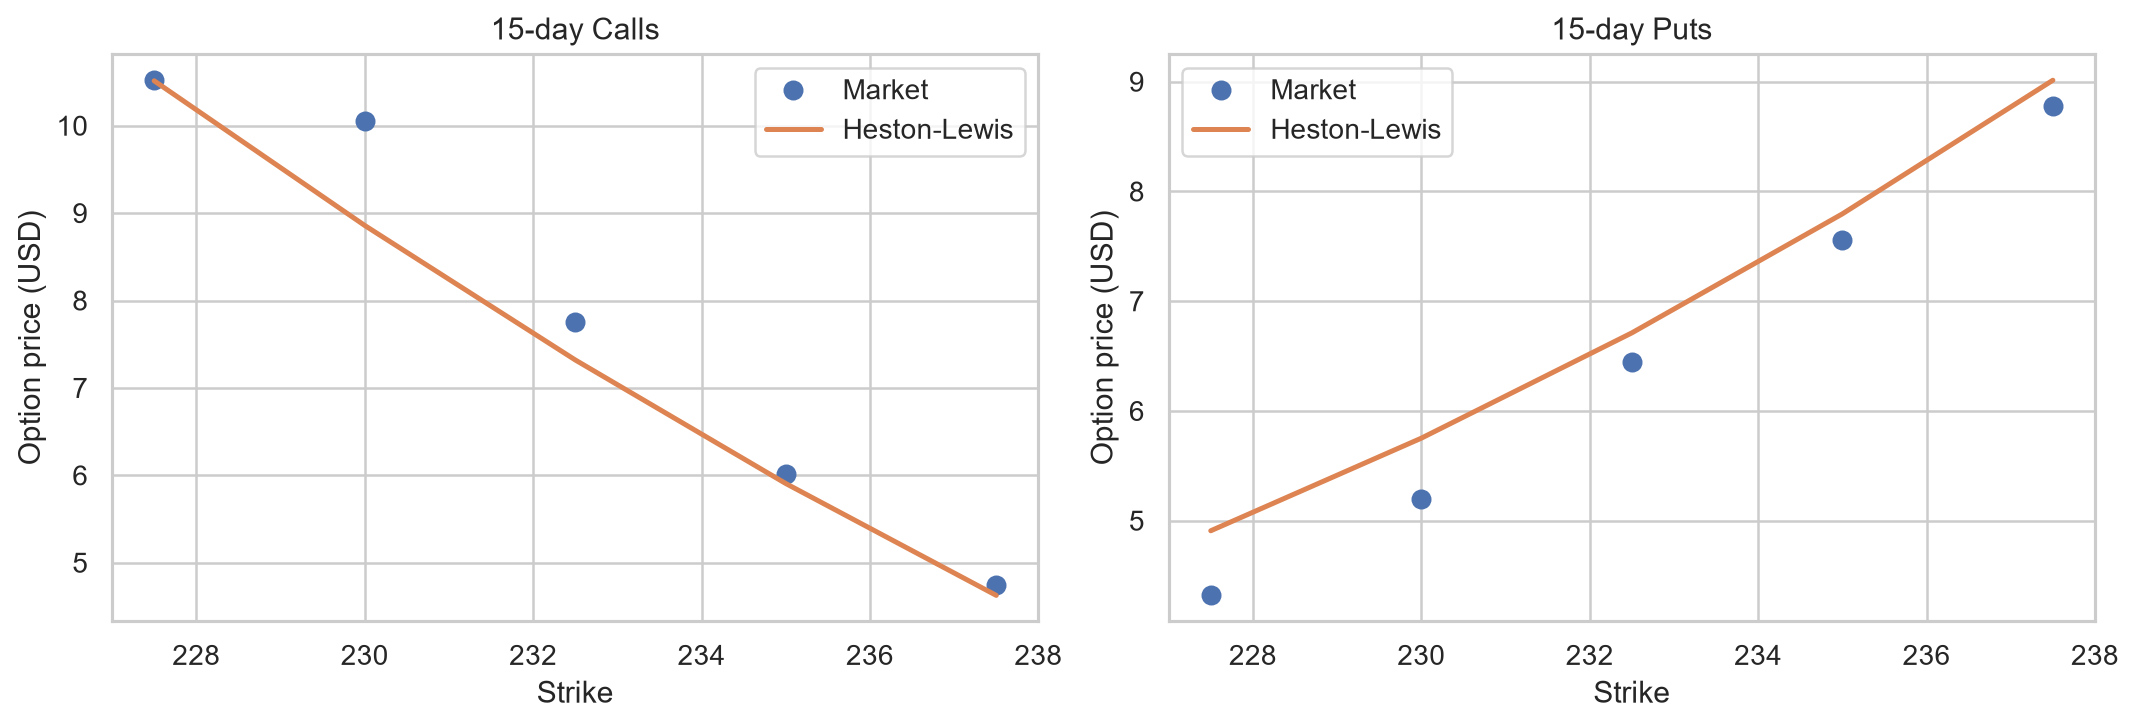

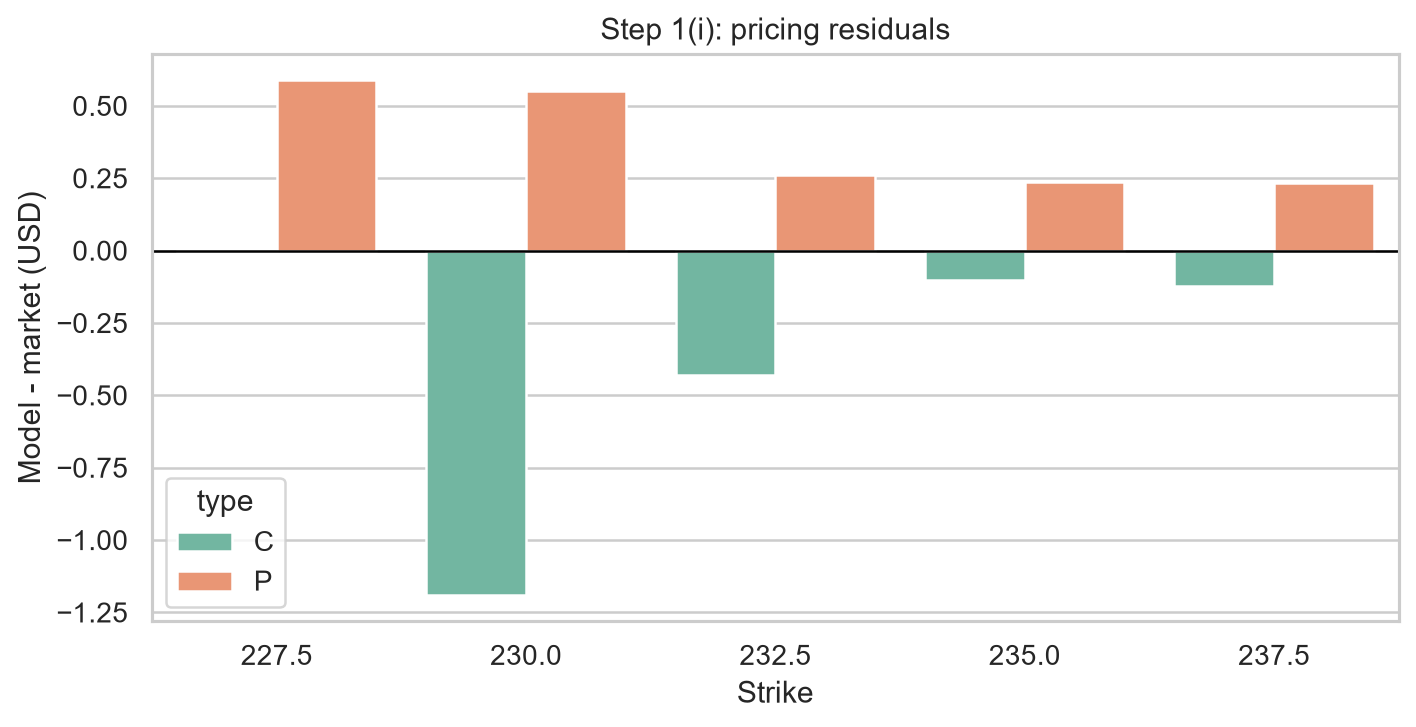

In [5]:
show_heston_lewis_fit()

### Step 1(i) interpretation

The reported result is the minimum of the regular price-MSE objective, using only the 15-day options. The parity diagnostic is essential: the input calls and puts are not mutually arbitrage-consistent at the stated spot and rate, so a model that derives puts by parity cannot fit both sides exactly. Short-maturity data also carry weak information about the long-run variance level and its mean-reversion speed. Parameter values at bounds or a failed Feller diagnostic should therefore be discussed as identification limitations, rather than interpreted as a forecast of long-run variance.

## 1(ii) Heston calibrated with Carr-Madan (1999)

> **Carr-Madan method purpose.** Carr-Madan damps the call-price function so its Fourier transform is integrable, providing an independent numerical route for pricing and calibrating the same Heston dynamics.

Carr-Madan prices the same characteristic function through a damped Fourier transform (Carr and Madan 61-73). For damping parameter $\alpha>0$, the transformed call value is

**Parameters (Equations 8-9).** $\psi_T(v)$ is the damped transform at Fourier frequency $v$ and maturity $T$; $\alpha>0$ is the damping parameter, $r$ is the risk-free rate, and $i=\sqrt{-1}$. $\phi_{\log S_T}$ is the characteristic function of the terminal log price. $C_0(K,T)$ is today's call value, $K$ is strike, and $\operatorname{Re}[\cdot]$ takes the real part of the integrand.

$$
\psi_T(v)=\frac{e^{-rT}\,\phi_{\log S_T}\!\left(v-(\alpha+1)i\right)}
{\alpha^2+\alpha-v^2+i(2\alpha+1)v}. \tag*{$\scriptstyle (8)$}
$$

$$
C_0(K,T)=\frac{e^{-\alpha\log K}}{\pi}
\int_0^{\infty}\operatorname{Re}\!\left[
e^{-iv\log K}\psi_T(v)\right]dv. \tag*{$\scriptstyle (9)$}
$$

The same 15-day observations, parameter bounds, regular MSE, and put-call parity convention are used. Agreement in fitted prices and MSE is the primary comparison; exact agreement in individual parameters is not guaranteed because the objective is shallow in poorly identified short-dated directions.

### Comparison procedure

The maturity, observations, parameter bounds, parity convention, optimizer sequence, and unweighted MSE are held fixed. Only the Fourier pricing representation changes. This controlled design makes fitted prices, objective values, and direct same-parameter price differences valid numerical comparisons; parameter equality is a weaker criterion when the short-maturity objective is flat.

,method,kappa,theta,sigma,rho,v0,MSE,RMSE
0,Lewis (2001),2.203249,0.00100,1.273325,-0.944421,0.108413,0.245839,0.495821
1,Carr-Madan (1999),0.050445,0.00104,1.253118,-0.938116,0.101870,0.245840,0.495823


,strike,Lewis,Carr-Madan,difference
0,227.5,10.513374,10.513410,-0.000036
1,232.5,7.320719,7.320706,0.000013
2,237.5,4.627330,4.627325,0.000005


#### Lewis versus Carr-Madan

**Numerical agreement.** The calibrations reach essentially identical losses: MSE 0.245839 for Lewis and 0.245840 for Carr-Madan. Holding the Lewis parameters fixed, the largest cross-method difference at the diagnostic strikes is only $0.000036. Because both methods evaluate the same risk-neutral Heston distribution through different transforms, this close agreement is a useful implementation check: numerical integration choice is not driving the reported option values.

**Why parameters differ.** Despite equal prices, kappa changes from 2.2032 to 0.0504. Short-dated options mainly identify current variance, skew, and short-run variance-of-variance; many kappa-theta combinations generate nearly the same 15-day distribution. This is evidence of an objective-function ridge, not a material disagreement between the two Fourier formulas. Consequently, fitted prices are stable even when individual parameters are not; risk management should emphasize price sensitivities and recalibration behavior rather than selecting a method because its kappa appears more plausible.

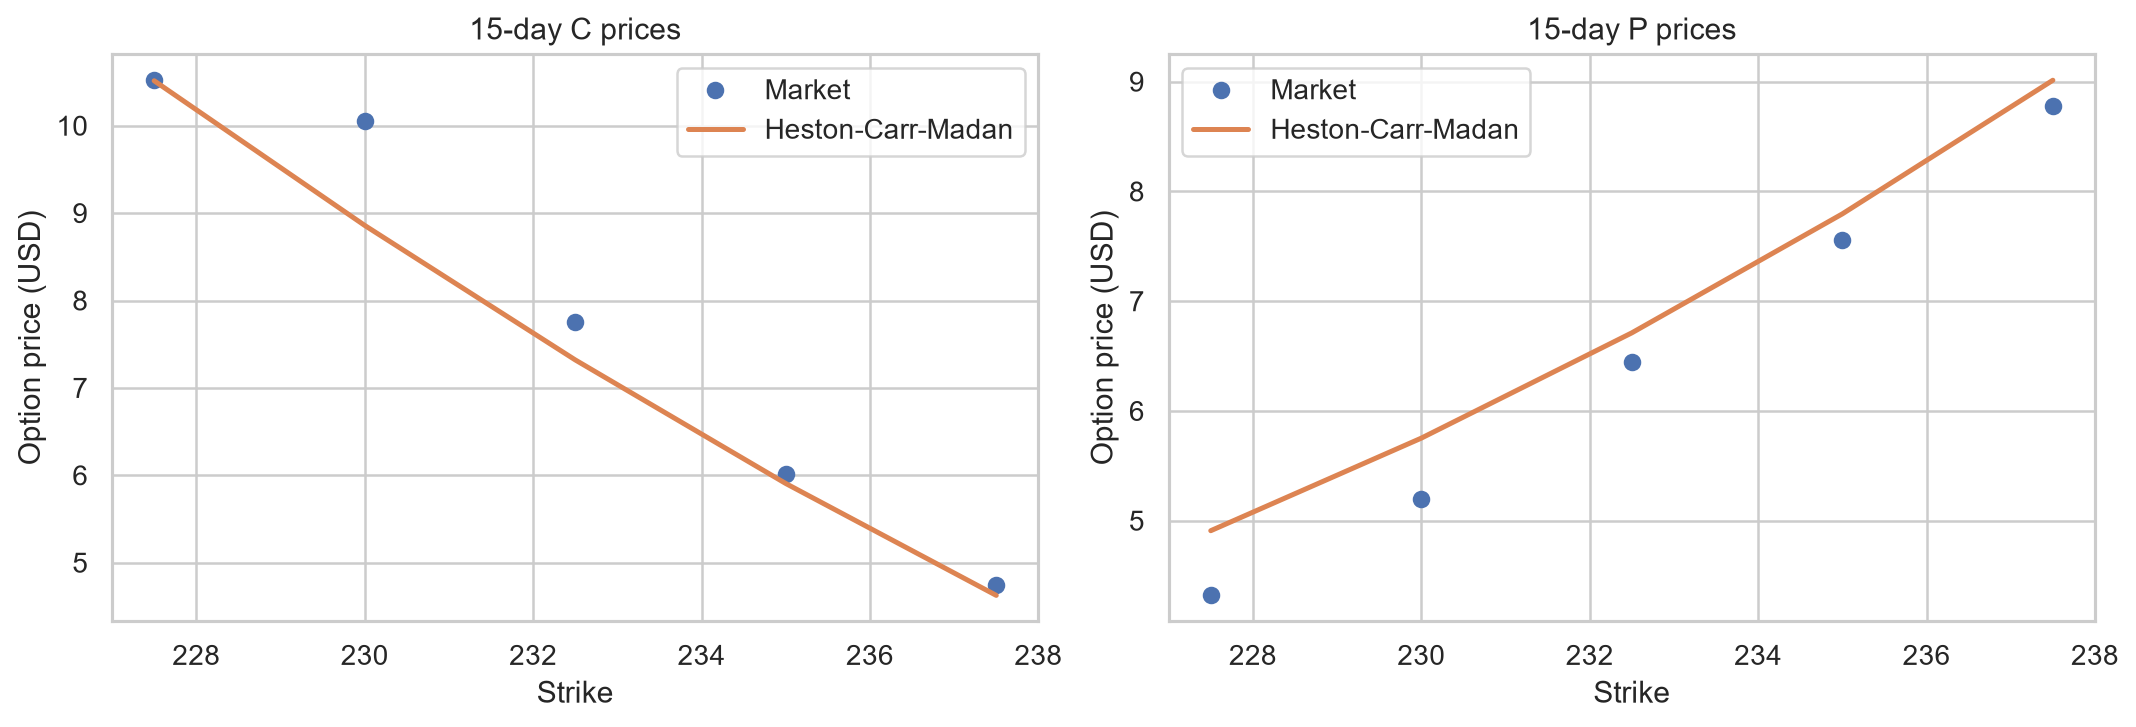

In [6]:
show_heston_carr_madan_calibration()

## 1(iii) Twenty-day ATM Asian call

> **Asian valuation purpose.** The arithmetic-average payoff reduces sensitivity to a single terminal stock price. Because the average depends on the complete simulated path, Monte Carlo valuation is used under the calibrated Heston dynamics.

The client requests an arithmetic-average Asian call with 20 trading days to maturity and strike equal to today's spot. The current spot is included as the first observation in the average, as required by the project brief (WorldQuant University 1-2):

**Parameters (Equations 10-13).** $A_T$ is the arithmetic average through maturity $T$; $n=20$ is the number of future daily observations, $j$ indexes observation dates $t_j$, and $S_{t_j}$ is the stock price at each date, including $S_{t_0}=S_0$. $\Pi_T$ is the Asian-call payoff and $K=S_0$ is its at-the-money strike. $\widehat{V}_0$ is the discounted Monte Carlo value, $M=200{,}000$ is the number of paths, $m$ indexes paths, $\Pi_T^{(m)}$ is path $m$'s payoff, and $r$ is the risk-free rate. $V_{\mathrm{client}}$ is the quoted value after multiplying fair value by $1.04$ to include the 4% fee.

$$
A_T=\frac{1}{n+1}\sum_{j=0}^{n}S_{t_j},\qquad S_{t_0}=S_0. \tag*{$\scriptstyle (10)$}
$$

$$
\Pi_T=\max(A_T-K,0),\qquad K=S_0. \tag*{$\scriptstyle (11)$}
$$

The discounted Monte Carlo estimator is

$$
\widehat{V}_0=e^{-rT}\frac{1}{M}\sum_{m=1}^{M}\Pi_T^{(m)}. \tag*{$\scriptstyle (12)$}
$$

Risk-neutral full-truncation simulation is used for the Heston variance process. The number of paths is reported with the standard error and a 95% confidence interval. The final client quote applies the required fee:

$$
V_{\mathrm{client}}=1.04\,\widehat{V}_0. \tag*{$\scriptstyle (13)$}
$$

### Monte Carlo procedure

The selected Heston calibration is simulated under the risk-neutral measure for 20 daily steps of $\Delta t=1/250$. Full truncation replaces negative Euler variance inputs by zero, correlated Gaussian shocks preserve the fitted leverage effect, and today's spot is included before the 20 simulated observations. The analysis uses 200,000 paths with a fixed seed, discounts every payoff at the risk-free rate, and reports both estimator uncertainty and the required commercial fee.

,paths,fair value,standard error,95% low,95% high,client price incl. 4% fee
0,200000,4.8177,0.013,4.7922,4.8432,5.0104


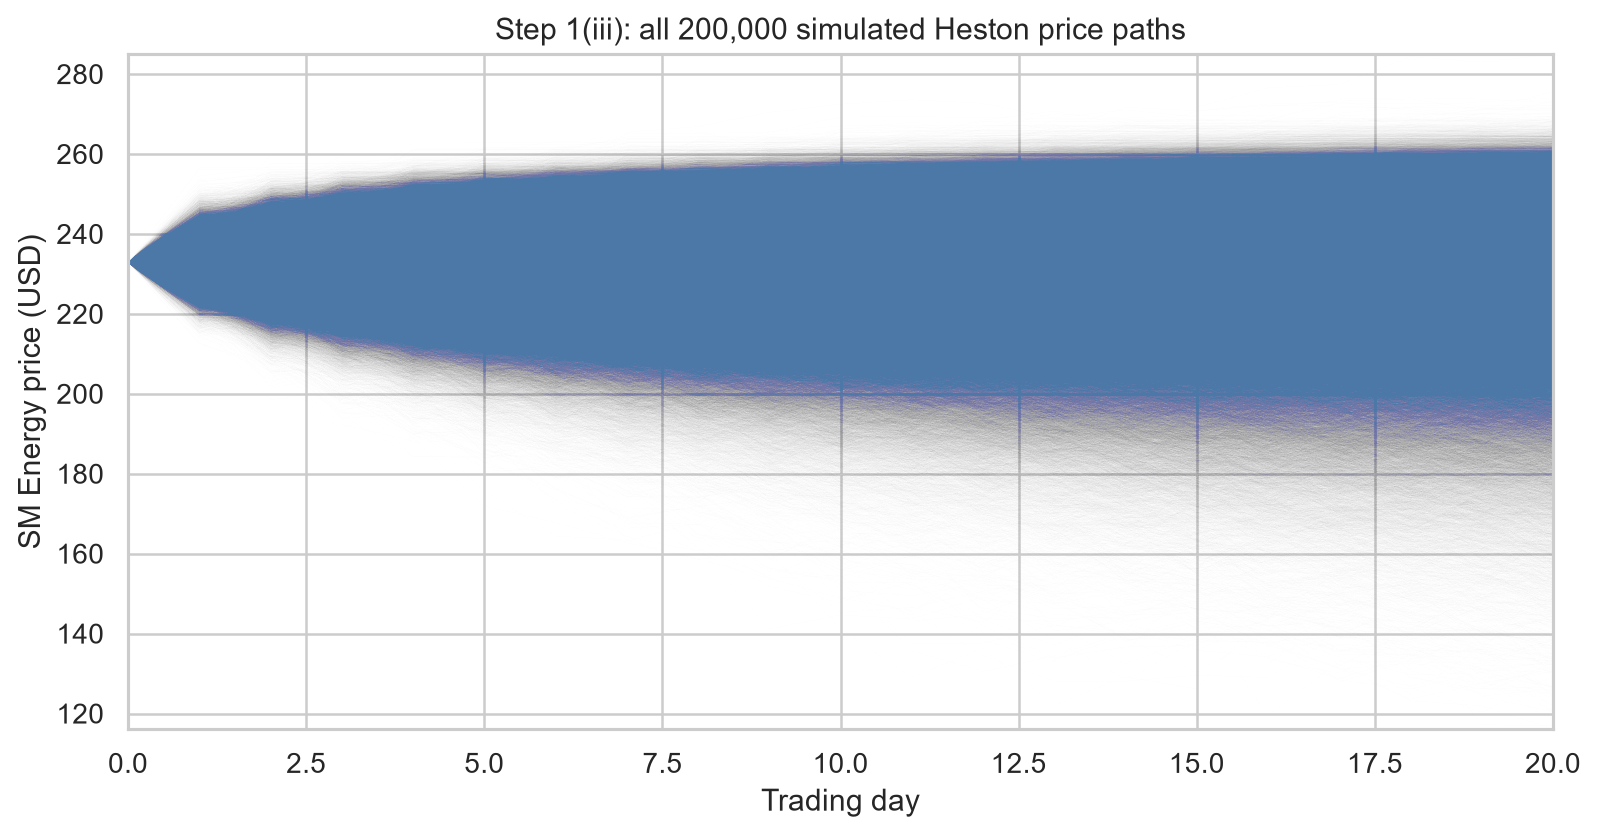

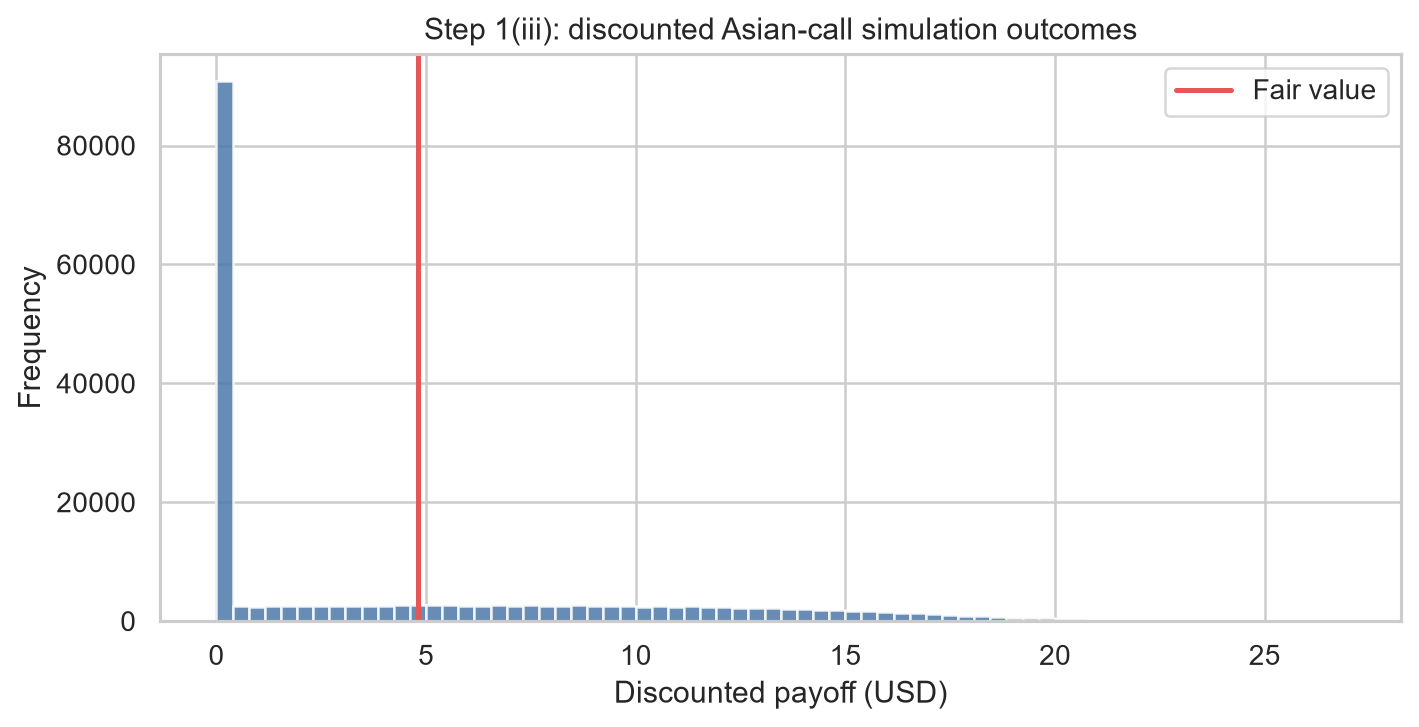

#### Valuation and client recommendation

**Simulation precision.** The fair value is $4.8177; its standard error is $0.0130, or 0.27% of the estimate. The 95% Monte Carlo interval of $4.7922 to $4.8432 is narrow enough that simulation noise is immaterial relative to calibration and model risk. The path plot shows every simulated daily trajectory, with the darkest region indicating the outcomes generated most often. The payoff histogram is right-skewed and contains many zero or small outcomes because the call pays only when the arithmetic average exceeds the strike. The vertical line is the probability-weighted mean of those outcomes, not the most likely realized payoff.

**Client quote.** Applying the required 4% fee gives $5.0104. In plain language, the quote is based on many plausible daily price paths inferred from traded options; averaging prices dampens the effect of any single day's move. The confidence interval measures numerical precision, not a guaranteed range for the eventual payoff. The 4% fee compensates the seller above model fair value but does not eliminate exposure to parameter uncertainty, discrete hedging, transaction costs, or a future volatility regime that differs from the calibration sample.

In [7]:
show_asian_call_valuation()

**Client-facing explanation.** We used prices from actively traded standard options to infer a range of plausible future movements for the stock over the requested time horizon. We then simulated many possible daily stock paths, calculated the option's average stock price on each path, and discounted the resulting payouts to today. The quoted amount includes the agreed 4% service fee. The confidence interval measures simulation precision, not a range of guaranteed future option values.

# Step 2 - Medium maturity (60 days)

## 2(i) Bates (1996) calibrated with Lewis (2001)

> **Bates model purpose.** Bates extends Heston by adding random discontinuous price jumps. The diffusion describes ordinary volatility dynamics, while jump intensity and jump-size parameters capture rare, abrupt moves that matter more at 60 days.

The Bates model augments the Heston process with a compound-Poisson jump component (Bates 69-107):

**Parameters (Equations 14-16).** $S_{t^-}$ is the stock price immediately before a jump; $r$, $v_t$, and $W_t^S$ retain their Heston meanings. $N_t$ is a Poisson jump count with intensity $\lambda$, $J=e^Y$ is the multiplicative jump size, and $Y$ is normal with mean $\mu_J$ and standard deviation $\delta_J$. The compensator $\kappa_J=\mathbb{E}[J-1]$ preserves the risk-neutral drift. $\varphi_J(u)$ is the jump characteristic-function multiplier at Fourier argument $u$ over maturity $T$, with $i=\sqrt{-1}$.

$$
\frac{dS_t}{S_{t^-}}=(r-\lambda\kappa_J)\,dt+\sqrt{v_t}\,dW_t^S
+(J-1)\,dN_t. \tag*{$\scriptstyle (14)$}
$$

For lognormal jump size $J=e^Y$, where $Y$ has mean $\mu_J$ and standard deviation $\delta_J$, the compensator is

$$
\kappa_J=\mathbb{E}[J-1]
=\exp\!\left(\mu_J+\frac{\delta_J^2}{2}\right)-1. \tag*{$\scriptstyle (15)$}
$$

The jump characteristic-function multiplier is

$$
\varphi_J(u)=\exp\!\left\{\lambda T
\left[\exp\!\left(iu\mu_J-\frac{1}{2}\delta_J^2u^2\right)-1-iu\kappa_J\right]\right\}. \tag*{$\scriptstyle (16)$}
$$

The additional parameters are jump intensity $\lambda$, mean log-jump $\mu_J$, and log-jump volatility $\delta_J$. Calibration uses the ten 60-day call and put observations and the same regular MSE; puts again follow Equation (6).

### Calibration procedure

The ten 60-day options are converted to $T=60/250=0.24$ years. The five Heston parameters and three jump parameters are estimated jointly by the same seeded global-search/local-refinement sequence and regular price MSE used in Step 1(i). Calls use the Lewis integral with the Bates characteristic function; puts use parity. Residual, parity, boundary, and Feller diagnostics are reviewed because adding jump flexibility does not make inconsistent quotes jointly attainable.

,kappa,theta,sigma,rho,v0,jump_intensity,jump_mean,jump_vol,MSE,RMSE
0,0.011436,0.001,0.151014,0.995,0.001,1.880979,0.213388,0.01,1.332442,1.154314


,days,strike,price,type,T,model,residual
0,60,227.5,16.78,C,0.24,17.3629,0.5829
1,60,230.0,17.65,C,0.24,16.4624,-1.1876
2,60,232.5,16.86,C,0.24,15.5689,-1.2911
3,60,235.0,16.05,C,0.24,14.6476,-1.4024
4,60,237.5,15.10,C,0.24,13.7327,-1.3673
5,60,227.5,11.03,P,0.24,11.1453,0.1153
6,60,230.0,12.15,P,0.24,12.7359,0.5859
7,60,232.5,13.37,P,0.24,14.3334,0.9634
8,60,235.0,14.75,P,0.24,15.9031,1.1531
9,60,237.5,15.62,P,0.24,17.4792,1.8592


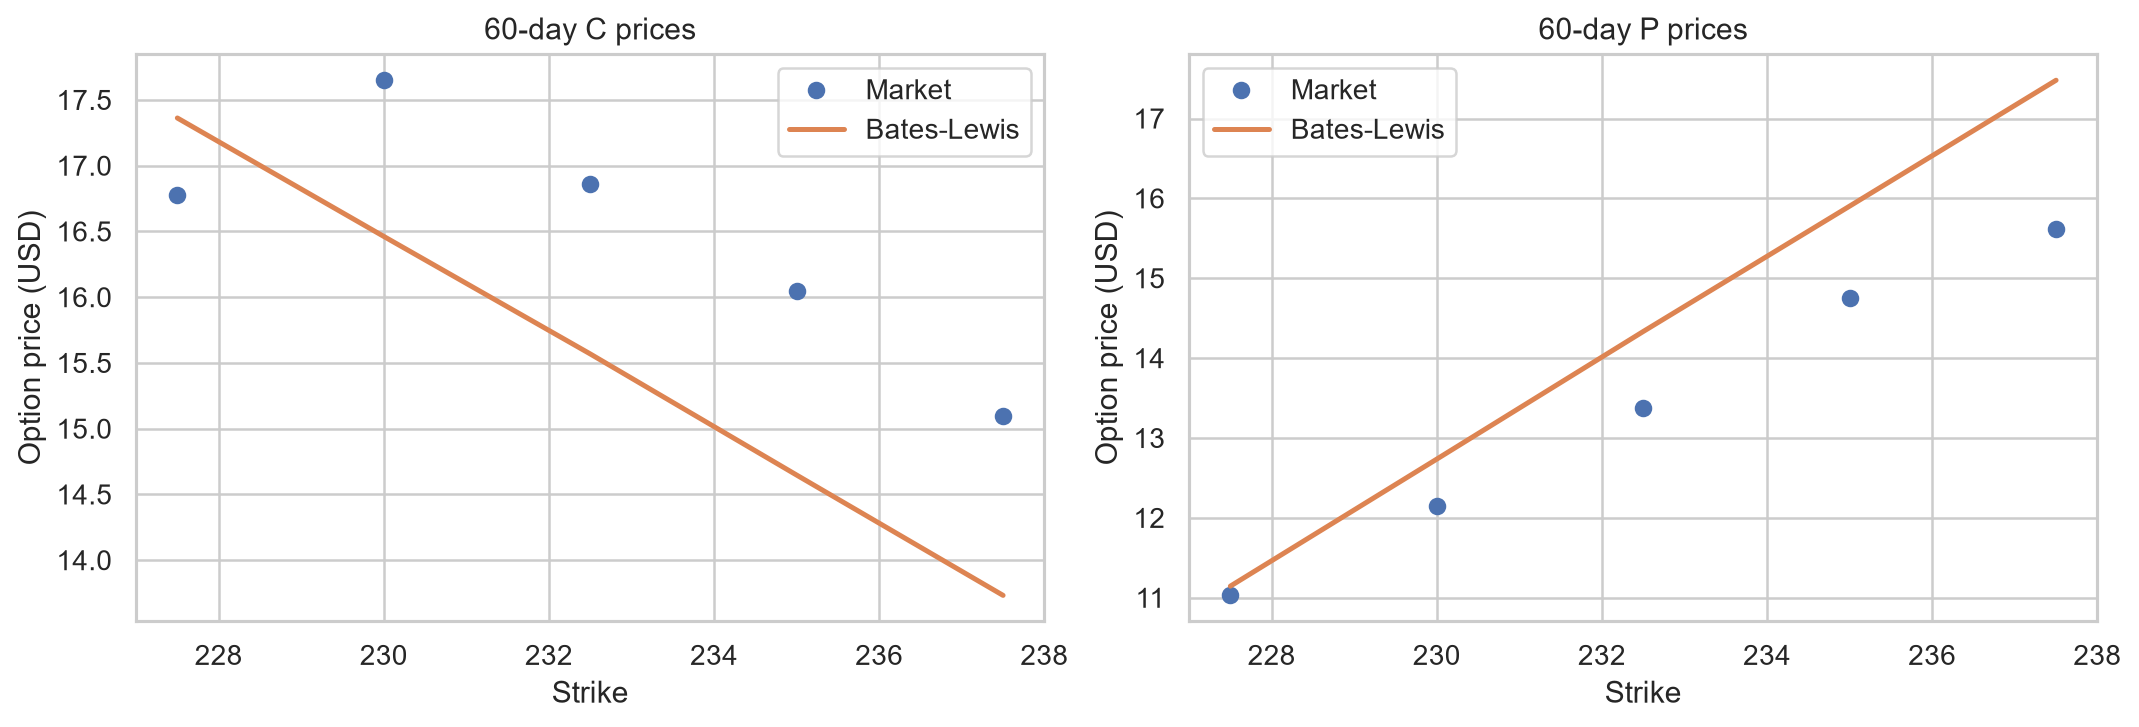

#### Bates calibration discussion

**Fit quality.** The 60-day RMSE is $1.1543. The observed calls are not monotonically decreasing at the lowest strikes, and the call-put pairs have parity RMSE $2.2533; an arbitrage-consistent model therefore cannot match every quote exactly. The plotted Bates curves smooth across these noisy or inconsistent observations, so visible gaps should not automatically be read as integration failure. They show the compromise required when one parameter vector is fitted jointly to all calls and puts.

**Jump interpretation.** Intensity 1.8810 implies a 36.33% probability of at least one jump over 60 trading days. Mean log-jump 0.2134 is positive, while jump volatility 0.0100 is at its lower bound. The optimizer is using an almost deterministic jump component to absorb shape in an inconsistent price cross-section. Thus the fitted jump probability describes the model's chosen risk-neutral mechanism for matching prices; it is neither a historical forecast of real-world jump frequency nor direct evidence that upward jumps are expected.

**Stability warning.** rho=0.995 is at the upper bound, theta and v0 are at their lower bounds, and the Feller diagnostic is -0.0228. The fit is usable for this near-maturity exercise, but the individual parameters should not be extrapolated as economic forecasts. Several parameters pressing against bounds also indicate that the available strikes do not contain enough independent information to identify all eight Bates parameters reliably; small quote changes may therefore produce large parameter changes.

In [8]:
show_bates_lewis_calibration()

## 2(ii) Bates (1996) calibrated with Carr-Madan (1999)

> **Bates-Carr-Madan purpose.** This specification keeps the Bates jump and stochastic-variance dynamics but evaluates prices with the damped Carr-Madan transform, providing a numerical cross-check against Lewis pricing.

This repeats the 60-day Bates calibration with the damped transform in Equations (8)-(9) (Carr and Madan 61-73). Any remaining difference from the Lewis result should be assessed against numerical integration tolerance and parameter identifiability, not simply judged by parameter equality.

### Comparison procedure

The Carr-Madan exercise changes only the numerical pricing transform. The 60-day sample, eight-parameter bounds, optimizer tolerances, parity construction, and objective remain unchanged. Similar MSE with different parameter vectors indicates weak identification or multiple near-minima; it does not by itself imply a pricing-engine error.

,method,kappa,theta,sigma,rho,v0,jump_intensity,jump_mean,jump_vol,MSE,RMSE
0,Lewis (2001),0.011436,0.001,0.151014,0.995,0.001,1.880979,0.213388,0.01,1.332442,1.154314
1,Carr-Madan (1999),14.900570,0.001,0.606112,0.995,0.001,1.879448,0.213242,0.01,1.333508,1.154776


#### Bates pricing-method comparison

**Price fit.** Lewis and Carr-Madan produce nearly the same loss: MSE 1.332442 versus 1.333508. This supports the numerical implementation of both characteristic-function integrations. The nearly overlapping fitted curves imply that the practical valuation conclusion is robust to the Fourier representation, even though neither representation can remove defects in the market cross-section.

**Parameter stability.** Jump intensity and mean jump size are nearly unchanged, but kappa moves from 0.0114 to 14.9006. Because both solutions sit on several bounds and have almost equal MSE, the objective has a flat or multi-modal direction. Price agreement is more credible than equality of every parameter. This distinction matters for use: either method can support interpolation near the calibrated contracts, but parameter-dependent stress tests or long-maturity extrapolations require additional stability checks.

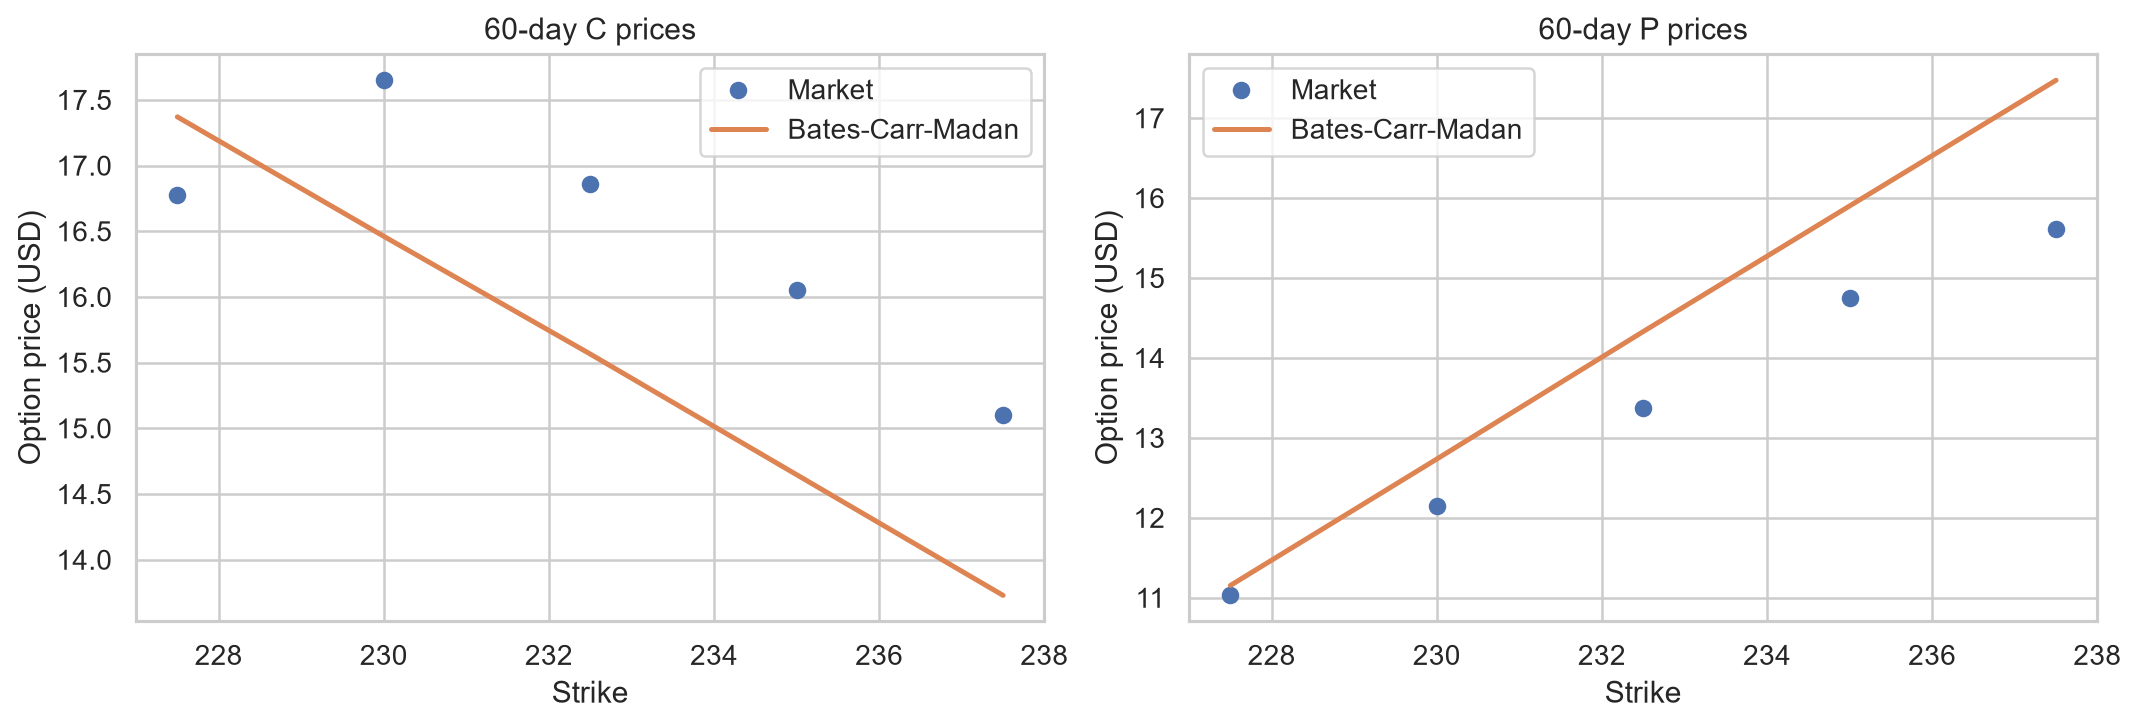

In [9]:
show_bates_carr_madan_calibration()

## 2(iii) Seventy-day, 95% moneyness vanilla put

> **Put-pricing purpose.** The calibrated Bates model converts the requested strike and 70-day horizon into a downside-protection value while retaining both stochastic volatility and jump risk.

The required strike is 95% of the current stock price (WorldQuant University 3):

**Parameters (Equation 17).** $K$ is the put strike, $S_0=232.90$ is the current SM Energy spot price, and $0.95$ is the assignment's 95% moneyness factor, giving $K=221.255$.

$$
K=0.95S_0=0.95(232.90)=221.255. \tag*{$\scriptstyle (17)$}
$$

The fair value uses the selected 60-day Bates calibration as the nearest available market-informed specification, extended to the required 70-day maturity. The same 4% fee convention from Equation (13) is applied to produce a client price.

In [10]:
show_seventy_day_put_valuation()

,spot,strike (95% spot),maturity (days),fair put value,client price incl. 4% fee
0,232.9,221.255,70,8.8187,9.1715


#### Pricing interpretation

The assignment's 95% moneyness convention gives K/S0=0.95 and strike $221.255. The selected Bates-Lewis calibration gives fair value $8.8187; adding the 4% fee produces a client price of $9.1715. Because the strike is below spot, the put begins out of the money and its value is entirely time value: the premium reflects the risk-neutral probability and severity of SM Energy falling below the strike before expiry, including the downside-tail contribution generated by stochastic volatility and jumps.

The maturity is ten trading days beyond the 60-day calibration set. This is a modest extrapolation, but the boundary-sensitive Bates parameters make model risk more important than numerical integration error. A production quote should be checked against fresh 60- to 70-day market data where available. The client price is therefore a model-based indication rather than a guaranteed hedge cost; liquidity, bid-ask spreads, recalibration risk, and the desk's hedging expenses may justify an additional commercial reserve beyond the stated fee.

# Step 3 - Interest-rate modelling

## 3(i) CIR (1985) calibration to the Euribor term structure

> **CIR model purpose.** CIR models a non-negative, mean-reverting short rate. Its closed-form zero-coupon bond prices connect the short-rate parameters to the observed Euribor term structure.

The supplied annualized Euribor observations are: 1 week 0.648%, 1 month 0.679%, 3 months 1.173%, 6 months 1.809%, and 12 months 2.556%. A cubic spline interpolates weekly annualized zero rates across one year, as required by the project brief (WorldQuant University 3-4). The CIR short-rate dynamics are (Cox, Ingersoll, and Ross 385-407):

**Parameters (Equations 18-23).** $r_t$ is the short rate at time $t$, $r_0$ is its initial value, $a$ is mean-reversion speed, $b$ is the long-run rate, $\eta$ is rate volatility, and $W_t$ is a Brownian motion. $P(0,T)$ is today's zero-coupon bond price for maturity $T$; $A(T)$ and $B(T)$ are the CIR affine bond coefficients and $\gamma=\sqrt{a^2+2\eta^2}$ is an auxiliary coefficient. $R(0,T)$ is the continuously compounded zero rate, while $\exp$ and $\log$ denote the exponential and natural logarithm.

$$
dr_t=a(b-r_t)\,dt+\eta\sqrt{r_t}\,dW_t. \tag*{$\scriptstyle (18)$}
$$

The CIR zero-coupon bond value and coefficients are

$$
P(0,T)=A(T)\exp[-B(T)r_0]. \tag*{$\scriptstyle (19)$}
$$

$$
B(T)=\frac{2(e^{\gamma T}-1)}{(\gamma+a)(e^{\gamma T}-1)+2\gamma}. \tag*{$\scriptstyle (20)$}
$$

$$
A(T)=\left[
\frac{2\gamma\exp((a+\gamma)T/2)}
{(\gamma+a)(e^{\gamma T}-1)+2\gamma}
\right]^{2ab/\eta^2}. \tag*{$\scriptstyle (21)$}
$$

$$
\gamma=\sqrt{a^2+2\eta^2}. \tag*{$\scriptstyle (22)$}
$$

The continuously compounded model zero rate is

$$
R(0,T)=-\frac{\log P(0,T)}{T}. \tag*{$\scriptstyle (23)$}
$$

Parameters $(a,b,\eta)$ are selected by least squares against the interpolated weekly curve. Negative spline values are clipped at zero because rates are modeled as non-negative in CIR.

### Curve-construction and calibration procedure

The five supplied annual rates are mapped to 7, 30, 90, 180, and 365 days. A natural cubic spline produces 52 weekly nodes from day 7 through day 364, with negative interpolated values floored at zero to remain consistent with CIR support. The one-week observation initializes the short rate. Differential evolution then minimizes the mean squared difference between the weekly spline and the continuously compounded CIR zero rates from Equations (19)-(23).

,a (mean reversion),b (long-run rate),eta (rate volatility),MSE,Feller diagnostic 2ab-eta^2
0,0.752509,0.07417,0.563833,6.200000e-07,-0.206281


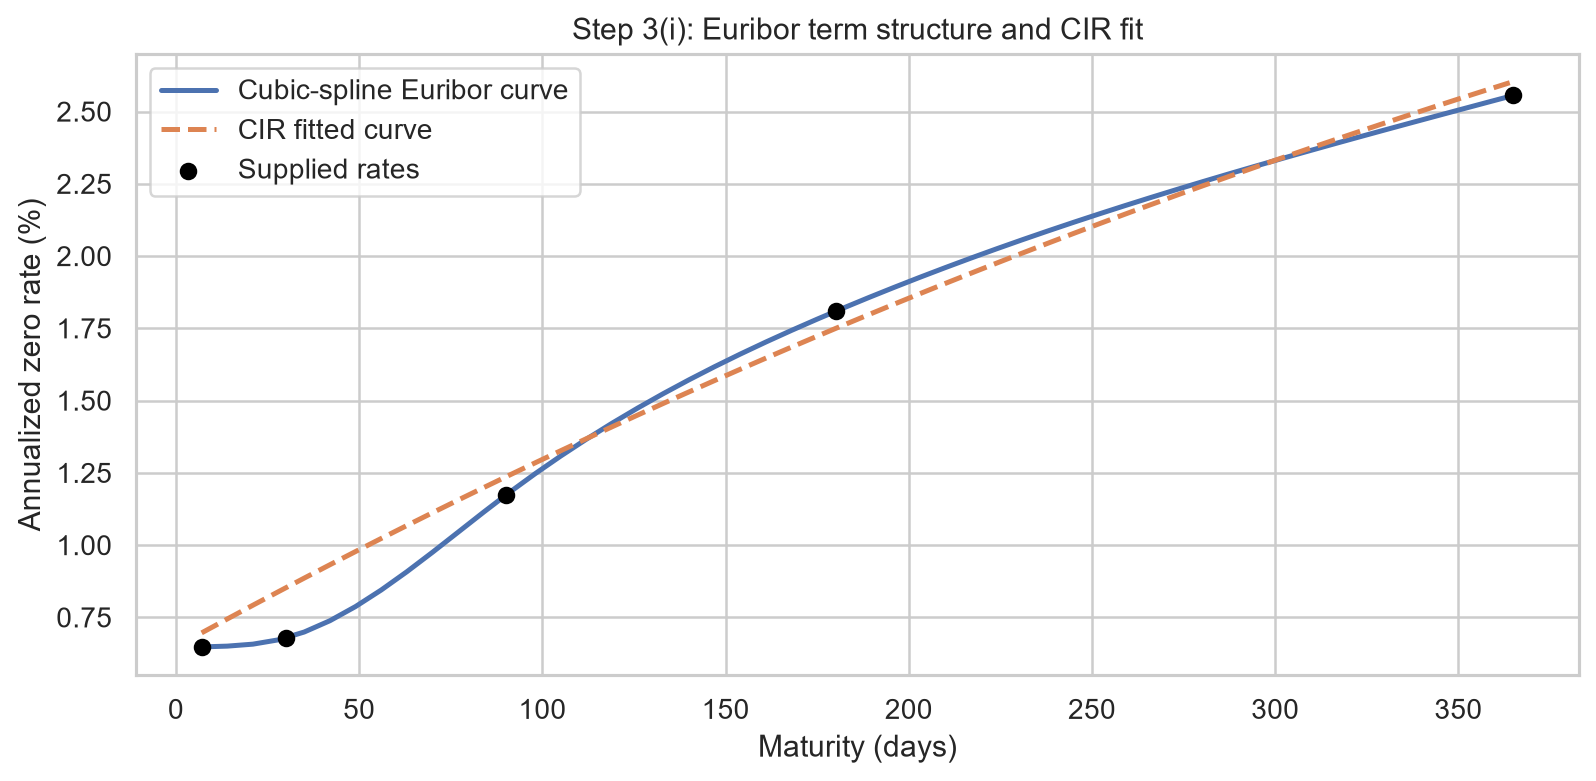

#### CIR calibration discussion

**Parameter interpretation.** Mean reversion a=0.7525 implies a half-life of about 0.92 years. Long-run level b=7.4170% lies above the current one-year Euribor of 2.5560%, creating upward drift. Volatility eta=0.5638 is large relative to the rate level and drives a wide, right-skewed forecast distribution. Mean reversion pulls rates toward b rather than allowing shocks to persist indefinitely, while the square-root volatility term makes absolute uncertainty smaller when rates are near zero and preserves non-negative simulated rates.

**Fit and limitation.** The curve RMSE is approximately 7.90 basis points, so the fitted line tracks the weekly spline closely. However, the Feller diagnostic is -0.2063, below zero, meaning the process can reach the zero boundary. The excellent in-sample fit does not remove long-horizon uncertainty inferred from only five supplied tenors. Moreover, the CIR curve is fitted to spline-interpolated observations, so the dense weekly line adds visual smoothness rather than new market information between the original tenor points.

In [11]:
show_cir_calibration()

## 3(ii) One-year daily CIR simulation

> **CIR simulation purpose.** Daily simulation propagates the calibrated rate dynamics one year forward, producing an expected terminal rate and a distribution for interest-rate risk rather than a single deterministic forecast.

One hundred thousand risk-neutral daily paths are simulated for one year using full truncation (WorldQuant University 4). The selected confidence level is 95%; the reported range is

**Parameters (Equations 24-25).** $r_{1\mathrm{y}}$ is the simulated terminal rate after one year and $Q_p(\cdot)$ is the $p$-quantile operator, so $Q_{0.025}$ and $Q_{0.975}$ form the central 95% range. $\widehat{\mathbb{E}}[r_{1\mathrm{y}}]$ is the Monte Carlo estimate of the expected terminal rate; $M=100{,}000$ is the number of paths, $m$ indexes paths, and $r_{1\mathrm{y}}^{(m)}$ is path $m$'s terminal rate.

$$
\left[Q_{0.025}(r_{1\mathrm{y}}),\,Q_{0.975}(r_{1\mathrm{y}})\right]. \tag*{$\scriptstyle (24)$}
$$

The expected terminal 12-month rate is estimated by the sample mean:

$$
\widehat{\mathbb{E}}[r_{1\mathrm{y}}]
=\frac{1}{M}\sum_{m=1}^{M}r_{1\mathrm{y}}^{(m)},\qquad M=100{,}000. \tag*{$\scriptstyle (25)$}
$$

The expected terminal rate is compared with the current 12-month Euribor rate. A higher expected rate increases discounting of future cash flows and, holding other inputs fixed, lowers present values of long-dated positive cash flows.

### Scenario procedure

Starting from the calibrated initial rate, 100,000 paths are advanced through 250 daily steps with $\Delta t=1/250$ and a fixed random seed. Full truncation evaluates the square-root diffusion at the non-negative part of the current rate and floors terminal rates at zero. The 2.5th and 97.5th percentiles form the selected 95% range; the sample mean estimates the expected terminal rate.

,paths,current 12M Euribor,expected 12M rate in one year,95% lower bound,95% upper bound
0,"100,000",2.5560%,4.2289%,0.0000%,25.0856%


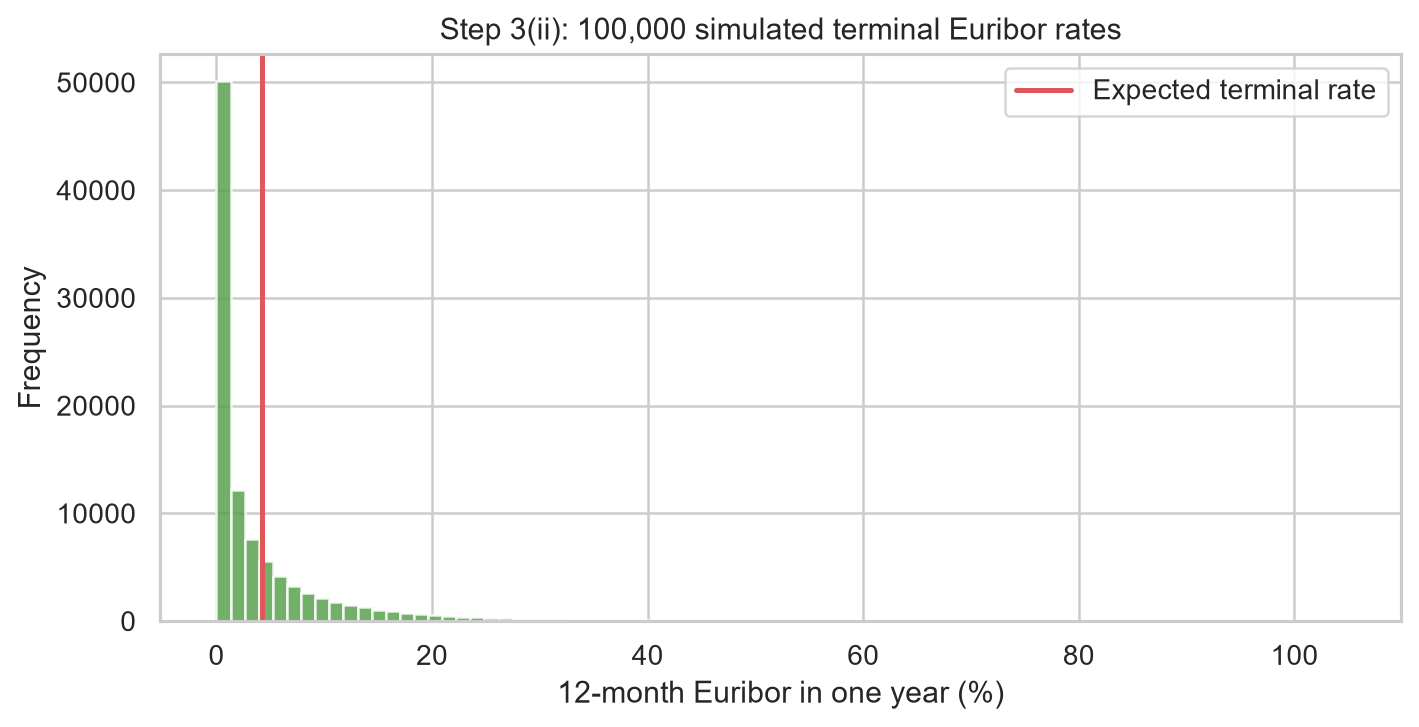

#### Rate-scenario discussion

**Distribution.** Expected one-year terminal rate 4.2289% is 167.3 basis points above current 12-month Euribor 2.5560%. The selected 95% interval is 0.0000% to 25.0856%. Its zero lower endpoint and long upper tail follow from the non-negative square-root process combined with high fitted volatility. The mean sits to the right of the histogram's most concentrated region because relatively rare high-rate scenarios pull the arithmetic average upward; the interval is a model-based scenario range, not a confidence interval for the estimated mean.

**Pricing implication.** If higher rates feed into the future discount curve, the present value of fixed positive cash flows falls and financing assumptions change. Option values move through both discounting and risk-neutral drift, so the direction is product-dependent rather than universally negative. The simulated short rate is used as a proxy for the requested 12-month Euribor; a production multi-curve model would represent that tenor and its spread explicitly. Decisions based on the tail scenarios should also account for parameter and curve-construction uncertainty, which is not included in the conditional Monte Carlo distribution shown here.

In [12]:
show_cir_scenarios()

# Conclusions and decision-oriented summary

- The 15-day Heston calibration is tailored to the requested short maturity. Its fit must be read alongside the observed put-call parity inconsistencies and short-horizon parameter-identification limits.
- The Asian-call fair value comes from a large set of risk-neutral scenarios, and the client quote applies the mandated 4% fee.
- The 60-day Bates exercise allows occasional discontinuous moves and is used for the 70-day put as the closest maturity-specific market calibration.
- The CIR analysis translates the Euribor curve into a one-year distribution of rates. The expected terminal rate and its 95% range support pricing and risk discussions for longer-dated products.

## Works Cited

Bates, David S. "Jumps and Stochastic Volatility: Exchange Rate Processes Implicit in Deutsche Mark Options." *The Review of Financial Studies*, vol. 9, no. 1, 1996, pp. 69-107. [doi:10.1093/rfs/9.1.69](https://doi.org/10.1093/rfs/9.1.69).

Carr, Peter, and Dilip B. Madan. "Option Valuation Using the Fast Fourier Transform." *The Journal of Computational Finance*, vol. 2, no. 4, 1999, pp. 61-73.

Cox, John C., Jonathan E. Ingersoll, Jr., and Stephen A. Ross. "A Theory of the Term Structure of Interest Rates." *Econometrica*, vol. 53, no. 2, 1985, pp. 385-407. [doi:10.2307/1911242](https://doi.org/10.2307/1911242).

Heston, Steven L. "A Closed-Form Solution for Options with Stochastic Volatility with Applications to Bond and Currency Options." *The Review of Financial Studies*, vol. 6, no. 2, 1993, pp. 327-343. [doi:10.1093/rfs/6.2.327](https://doi.org/10.1093/rfs/6.2.327).

Lewis, Alan L. "A Simple Option Formula for General Jump-Diffusion and Other Exponential Levy Processes." *SSRN*, 2001, [ssrn.com/abstract=282110](https://ssrn.com/abstract=282110).

WorldQuant University. *MScFE 622 Stochastic Modeling: Group Work Project 1*. 2022. Course handout.

# Step 4 - Submission checklist

The analytical material, figures, and references are organized for the required report and archive. The presentation export suppresses inputs while retaining explanations, tables, and figures.

In [13]:
refresh_narrative_sidecar()

README.md refreshed with the current narrative and results.
